## model definition

prenorm + rope + swiglu with weight tying for the embed / unembed matrix

use vanilla mha since using grouped mqa or mqa is unnecessary for the scale of this exercise and we aren't doing kv cached inference.

In [3]:
from dataclasses import dataclass
from flax import nnx

@dataclass
class MoEConfig:
  experts_per_token: int
  experts: int

@dataclass
class ModelConfig:
  hidden_size: int
  ffw_size: int
  layers: int
  attn_heads: int
  vocab_size: int
  moe_config: MoEConfig | None

  def size(self, *, active=True):
      attn_params = 4*self.hidden_size**2 + self.hidden_size
      if not self.moe_config:
          mlp_params = 3*self.hidden_size*self.ffw_size + self.hidden_size + self.ffw_size
      else:
          k = self.moe_config.experts_per_token if active else self.moe_config.experts
          mlp_params = 3*self.hidden_size*self.ffw_size*k + self.hidden_size + self.ffw_size
      return self.layers*(attn_params + mlp_params) + self.vocab_size*self.hidden_size


class RMSNorm(nnx.Module):
  def __init__(self, config):
    hidden_size = config.hidden_size
    self.gamma = nnx.Param(jnp.ones((hidden_size,)))

  def __call__(self, x):
    inv_norm = jax.lax.rsqrt(jnp.mean(x**2, axis=-1) + 1e-6)[..., None]
    return self.gamma * x * inv_norm


class RoPE(nnx.Module):
  def _create_inv_freqs(self, base, head_size):
    assert head_size % 2 == 0
    inds = jnp.arange(head_size // 2)
    return base ** (-2 * inds / head_size)

  def _create_cos_sin(self, T, inv_freqs):
    # [1, T, 1, 1]
    positions = jnp.arange(T)[None, :, None, None]
    dupl_inv_freqs = jnp.concat([inv_freqs, inv_freqs])[None, None, None, :]
    freqs = positions * dupl_inv_freqs
    return jnp.cos(freqs), jnp.sin(freqs)

  def _rotate_half(self, x):
    # x[B, T, N, H]
    H = x.shape[-1]
    even = jax.lax.dynamic_slice_in_dim(x, 0, H//2, axis=-1)
    odd = jax.lax.dynamic_slice_in_dim(x, H//2, H//2, axis=-1)
    return jnp.concat([-odd, even], axis=-1)

  def __init__(self, config, base=10_000):
    head_size = config.hidden_size // config.attn_heads
    self.base = base
    self.inv_freqs = self._create_inv_freqs(base, head_size)

  def __call__(self, x):
    B, T, N, H = x.shape
    cos, sin = self._create_cos_sin(T, self.inv_freqs)
    return x * cos + self._rotate_half(x) * sin


class MHA(nnx.Module):
  def __init__(self, config, *, rngs):
    self.config = config
    hidden_size = config.hidden_size
    self.pre_norm = RMSNorm(config)
    self.rope = RoPE(config)
    self.qkv_proj = nnx.Param(0.02 * jax.random.normal(rngs.params(), (hidden_size, 3 * hidden_size)))
    self.o_proj = nnx.Param(0.02 * jax.random.normal(rngs.params(), (hidden_size, hidden_size)))

  def _sdpa(self, q, k, v):
    B, T, N, H = q.shape
    S = k.shape[1]
    logits = jnp.einsum('btnh,bsnh->btsn', q, k)
    scaled_logits = (H ** -0.5) * logits
    mask = jnp.tril(jnp.ones((T, S), dtype=jnp.bool))[None, :, :, None]
    masked_scaled_logits = jnp.where(mask, scaled_logits, -jnp.inf)
    weights = jax.nn.softmax(masked_scaled_logits, axis=2)
    attn_out = jnp.einsum('btsn,bsnh->btnh', weights, v)
    return attn_out

  def __call__(self, x):
    B, T, D = x.shape
    N = self.config.attn_heads
    H = D//N
    t = self.pre_norm(x)
    qkv = jnp.einsum('btd,df->btf', t, self.qkv_proj)
    q = jax.lax.dynamic_slice_in_dim(qkv, 0, D, axis=-1).reshape((B, T, N, H))
    q = self.rope(q)
    k = jax.lax.dynamic_slice_in_dim(qkv, D, D, axis=-1).reshape((B, T, N, H))
    k = self.rope(k)
    v = jax.lax.dynamic_slice_in_dim(qkv, 2*D, D, axis=-1).reshape((B, T, N, H))
    attn_out = self._sdpa(q, k, v).reshape((B, T, D))
    out = jnp.einsum('btd,df->btf', attn_out, self.o_proj)
    return x + out


class MLP(nnx.Module):
  def __init__(self, config, *, rngs):
    self.config = config
    hidden_size = config.hidden_size
    ffw_size = config.ffw_size
    moe_config = config.moe_config
    self.pre_norm = RMSNorm(config)
    if moe_config:
      E, k = moe_config.experts, moe_config.experts_per_token
      self.router = nnx.Param(0.02 * jax.random.normal(rngs.params(), (hidden_size, E)))
      self.glu_proj1 = nnx.Param(0.02 * jax.random.normal(rngs.params(), (E, hidden_size, ffw_size)))
      self.glu_proj2 = nnx.Param(0.02 * jax.random.normal(rngs.params(), (E, hidden_size, ffw_size)))
      self.down_proj = nnx.Param(0.02 * jax.random.normal(rngs.params(), (E, ffw_size, hidden_size)))
    else:
      self.glu_proj1 = nnx.Param(0.02 * jax.random.normal(rngs.params(), (hidden_size, ffw_size)))
      self.glu_proj2 = nnx.Param(0.02 * jax.random.normal(rngs.params(), (hidden_size, ffw_size)))
      self.down_proj = nnx.Param(0.02 * jax.random.normal(rngs.params(), (ffw_size, hidden_size)))
    self.beta = nnx.Param(jnp.ones(ffw_size))



  def __call__(self, x):
    moe_config = self.config.moe_config
    ffw_size = self.config.ffw_size
    t = self.pre_norm(x)
    if moe_config:
      k, E = moe_config.experts_per_token, moe_config.experts
      router_logits = jnp.einsum('btd,de->bte', t, self.router)
      router_weights = jax.nn.softmax(router_logits, axis=-1)
      top_k_weights, top_k_experts = jax.lax.top_k(router_weights, k)
      B, T, D = t.shape
      flattened_x = t.reshape((B*T, D))
      flattened_x_inds_padded = jnp.repeat(jnp.arange(B*T)[:, None], k, axis=-1)
      flattened_x_inds_padded = flattened_x_inds_padded.reshape((B*T*k,))
      flattened_routed_experts = top_k_experts.reshape((B*T*k,))
      sorted_routed_experts_inds = jnp.argsort(flattened_routed_experts)
      sizes = jnp.bincount(flattened_routed_experts, minlength=E, length=E)
      sorted_flattened_x_inds = flattened_x_inds_padded[sorted_routed_experts_inds]
      sorted_flat_x = flattened_x[sorted_flattened_x_inds]

      f1 = jax.lax.ragged_dot(sorted_flat_x, self.glu_proj1[...], sizes)
      f2 = jax.lax.ragged_dot(sorted_flat_x, self.glu_proj2[...], sizes)
      swiglu_out = f1 * f2 * jax.nn.sigmoid(self.beta * f2)
      out = jax.lax.ragged_dot(swiglu_out, self.down_proj[...], sizes)

      out = out[jnp.argsort(sorted_routed_experts_inds)]
      out = out.reshape((B, T, k, D))
      out = jnp.sum(top_k_weights[..., None] * out, axis=2)

      total = B * T
      f = sizes / total
      p = jnp.sum(router_weights, axis=[0, 1]) / total
      return x + out, p, f
    else:
      f1 = jnp.einsum('btd,df->btf', t, self.glu_proj1)
      f2 = jnp.einsum('btd,df->btf', t, self.glu_proj2)
      t = f1 * f2 * jax.nn.sigmoid(self.beta * f2)
      out = jnp.einsum('btf,fd->btd', t, self.down_proj)
      return x + out


class TransformerLayer(nnx.Module):
  def __init__(self, config, *, rngs):
    self.attn_block = MHA(config, rngs=rngs)
    self.mlp_block = MLP(config, rngs=rngs)

  def __call__(self, x):
    t = self.attn_block(x)
    return self.mlp_block(t)


class Transformer(nnx.Module):
  def __init__(self, config, *, rngs):
    hidden_size = config.hidden_size
    vocab_size = config.vocab_size
    self.is_moe = config.moe_config is not None
    self.embed = nnx.Param(0.02 * jax.random.normal(rngs.params(), (vocab_size, hidden_size)))
    self.layers = [TransformerLayer(config, rngs=rngs) for _ in range(config.layers)]

  def __call__(self, x):
    x = self.embed[x]
    ps = []
    fs = []
    for l in self.layers:
      if self.is_moe:
        x, p, f = l(x)
        ps.append(p)
        fs.append(f)
      else:
        x = l(x)

    logits = jnp.einsum('btd,vd->btv', x, self.embed)
    if self.is_moe:
      return logits, jnp.vstack(ps), jnp.vstack(fs)

    return logits

In [ ]:
import numpy as np
import jax
import jax.numpy as jnp


class NaiveMoEMLP(nnx.Module):
    def __init__(self, config, pre_norm, router, glu_proj1, glu_proj2, down_proj, beta):
      self.config = config
      self.pre_norm = pre_norm
      self.router = router
      self.glu_proj1 = glu_proj1
      self.glu_proj2 = glu_proj2
      self.down_proj = down_proj
      self.beta = beta

    def __call__(self, x):
        k = self.config.moe_config.experts_per_token
        x_n = self.pre_norm(x)
        E, F, D = self.down_proj.shape
        B, T, D = x.shape
        router_logits = jnp.einsum('btd,de->bte', x_n, self.router)
        router_weights = jax.nn.softmax(router_logits, axis=-1)
        top_k_weights, top_k_experts = jax.lax.top_k(router_weights, k)

        out = jnp.zeros((B, T, D))
        for b in range(B):
            for t in range(T):
                tok = x_n[b, t]
                top_k = top_k_experts[b, t]
                k_glu_proj1 = self.glu_proj1[top_k]
                k_glu_proj2 = self.glu_proj2[top_k]
                f1 = jnp.einsum('d,kdf->kf', tok, k_glu_proj1)
                f2 = jnp.einsum('d,kdf->kf', tok, k_glu_proj2)
                tmp = f1 * f2 * jax.nn.sigmoid(self.beta * f2)
                k_down_proj = self.down_proj[top_k]
                tmp = jnp.einsum('kf,kfd->kd', tmp, k_down_proj)
                k_weights = top_k_weights[b, t]
                tok_out = jnp.sum(k_weights[:, None] * tmp, axis=0)
                out = out.at[b, t].set(tok_out)

        return x + out


B, T, D, F, k, E = 2, 2, 4, 16, 2, 4

moe_config = MoEConfig(
  experts_per_token=k,
  experts=E
)

config = ModelConfig(
  hidden_size=D,
  ffw_size=F,
  layers=2,
  attn_heads=2,
  vocab_size=3,
  moe_config=moe_config
)

rngs = nnx.Rngs(0)
moe_mlp = MLP(config, rngs=rngs)
moe_naive = NaiveMoEMLP(config, moe_mlp.pre_norm, moe_mlp.router, moe_mlp.glu_proj1, moe_mlp.glu_proj2, moe_mlp.down_proj, moe_mlp.beta)
x = jax.random.normal(rngs.params(), (B, T, D))
moe_out, _, _ = moe_mlp(x)
moe_baseline = moe_naive(x)

print('moe_out shape:', moe_out.shape)
print('moe_baseline shape:', moe_baseline.shape)

np.testing.assert_array_almost_equal(moe_out, moe_baseline)

moe_out shape: (2, 2, 4)
moe_baseline shape: (2, 2, 4)


## basic training loop

config:

D=256
F=4*256
L=10
N=4
=> ~10.5M params

In [ ]:
import jax
import jax.numpy as jnp
import optax
from optax.losses import softmax_cross_entropy_with_integer_labels as softmax_ce_loss
import functools


MAX_OPERAND = 999
SPACE = 10
PLUS = 11
EQUAL = 12
EOS = 13
MAX_SEQ_LEN = 17

# to make the task harder, spaces are randomly generated
def gen_seq(key):
    key, op_key, space_key = jax.random.split(key, 3)
    ops = jax.random.choice(op_key, MAX_OPERAND, shape=(2,))
    ops_res = jnp.concat([ops, jnp.sum(ops, keepdims=True)])
    mults = 10**(jnp.array([-3.0, -2.0, -1.0, 0.0]))[None, :]
    digits = (mults * ops_res[:, None]).astype(jnp.int16) % 10
    e3_mask = digits[:, 0:1] > 0
    e2_mask = jnp.logical_or(e3_mask, digits[:, 1:2] > 0)
    e1_mask = jnp.logical_or(e2_mask, digits[:, 2:3] > 0)
    digits_mask = jnp.concat([
        e3_mask,
        e2_mask,
        e1_mask,
        jnp.array([True, True, True]).reshape((3, 1))
    ], axis=-1)
    spaces_mask = jax.random.choice(space_key, 2, shape=(4,)).astype(jnp.bool)
    full_seq = jnp.concat([
        digits[0],
        jnp.array([SPACE]),
        jnp.array([PLUS]),
        jnp.array([SPACE]),
        digits[1],
        jnp.array([SPACE]),
        jnp.array([EQUAL]),
        jnp.array([SPACE]),
        digits[2],
        jnp.array([EOS])
    ])
    full_seq_mask = jnp.concat([
        digits_mask[0],
        spaces_mask[0].reshape((1,)),
        jnp.array([True]),
        spaces_mask[1].reshape((1,)),
        digits_mask[1],
        spaces_mask[2].reshape((1,)),
        jnp.array([True]),
        spaces_mask[3].reshape((1,)),
        digits_mask[2],
        jnp.array([True])
    ])
    seq = jnp.full(MAX_SEQ_LEN+1, SPACE)
    inds = jnp.cumsum(full_seq_mask.astype(jnp.int8)) - 1
    inds = jnp.where(full_seq_mask, inds, -1)
    seq = seq.at[inds].set(full_seq)
    seq = seq[:MAX_SEQ_LEN]

    prompt_len = jnp.sum(e2_mask[:-1, :].astype(jnp.int8)) + jnp.sum(e1_mask[:-1, :].astype(jnp.int8)) + 2 + 2 + jnp.sum(spaces_mask.astype(jnp.int8))
    t = jnp.arange(MAX_SEQ_LEN-1)
    valid_loss_mask = jnp.logical_and(
        t >= prompt_len - 1,
        t < full_seq_mask.astype(jnp.int8).sum() - 1
    )
    return seq, valid_loss_mask


def gen_batch(bs, key):
    return jax.vmap(gen_seq)(jax.random.split(key, bs))


def decode(enc_arr):
    a = []
    for i in enc_arr.tolist():
        if i == SPACE:
            a.append(' ')
        elif i == PLUS:
            a.append('+')
        elif i == EQUAL:
            a.append('=')
        elif i == EOS:
            a.append('<|EOS|>')
        else:
            a.append(str(i))

    return "".join(a)


# reuse input state buffer so we're not storing 2x model+opt state unnecessarily
@functools.partial(jax.jit, donate_argnums=(0,), static_argnames=('bs', 'n', 'load_bal_alpha'))
def scan(state, graphdef, key, n, bs, load_bal_alpha):
    def f(carry, _):
        state, key = carry
        model, opt = nnx.merge(graphdef, state)
        key, subkey = jax.random.split(key)
        batch, loss_mask = gen_batch(bs, subkey)
        def loss_fn(model):
            if load_bal_alpha > 0:
                logits, ps, fs = model(batch[:, :-1])
                E = ps.shape[-1]
                load_balancing_loss = load_bal_alpha * E * jnp.sum(ps * fs)
            else:
                logits = model(batch[:, :-1])
                load_balancing_loss = jnp.array(0.0)
            labels = batch[:, 1:]
            losses = softmax_ce_loss(logits, labels)
            m = loss_mask.astype(jnp.int8)
            ce_loss = jnp.sum(m * losses) / jnp.sum(m)
            return ce_loss + load_balancing_loss, (ce_loss, load_balancing_loss)

        loss, grads = nnx.value_and_grad(loss_fn, has_aux=True)(model)
        opt.update(model, grads)
        _, state = nnx.split((model, opt))
        return (state, key), loss

    carry, losses = jax.lax.scan(f, (state, key), length=n)
    state, _ = carry
    return state, losses


def train_n_steps(model, opt, bs, n, key, load_bal_alpha):
    graphdef, state = nnx.split((model, opt))
    state, losses = scan(state, graphdef, key, n, bs, load_bal_alpha)
    nnx.update((model, opt), state)
    return losses


@dataclass
class TrainingConfig:
    max_lr: float
    min_lr: float
    steps: int
    flops: int
    warmup_steps: int
    bs: int
    seed: int
    print_every: int
    load_bal_alpha: float
    chunk_size: int = 100


def train_model(model_config, training_config):
    rngs = nnx.Rngs(params=training_config.seed, batch=training_config.seed+1)
    model = Transformer(model_config, rngs=rngs)
    lr_schedule = optax.warmup_cosine_decay_schedule(
        init_value=0.0,
        peak_value=training_config.max_lr,
        warmup_steps=training_config.warmup_steps,
        decay_steps=training_config.steps - training_config.warmup_steps,
        end_value=training_config.min_lr
    )
    opt = nnx.Optimizer(
        model,
        optax.chain(
            optax.clip_by_global_norm(1.0),
            optax.adamw(learning_rate=lr_schedule)
        ),
        wrt=nnx.Param
    )
    chunks = int(training_config.steps // training_config.chunk_size)
    # want exact FLOPS as counted and don't want to recompile with a different n
    assert training_config.steps % training_config.chunk_size == 0
    assert training_config.print_every % training_config.chunk_size == 0
    losses = []
    ce_losses = []
    aux_losses = []

    print(f'--- starting run for model of size {model_config.size():1.2e} ---')
    for c in range(chunks):
        losses_jnp, losses_split_jnp = train_n_steps(
            model,
            opt,
            training_config.bs,
            training_config.chunk_size,
            rngs.batch(),
            training_config.load_bal_alpha
        )
        ce_losses_jnp, aux_losses_jnp = losses_split_jnp
        losses.extend(losses_jnp.tolist())
        if model_config.moe_config:
            ce_losses.extend(ce_losses_jnp.tolist())
            aux_losses.extend(aux_losses_jnp.tolist())

        step = (c+1)*training_config.chunk_size
        if step % training_config.print_every == 0:
          print(f'step: {step}, loss: {losses[-1]}' + (f', ce_loss: {ce_losses[-1]}, aux_loss: {aux_losses[-1]}' if model_config.moe_config else ''))

    if model_config.moe_config:
        return losses, ce_losses, aux_losses
    else:
        return losses

## preliminary runs
run a subset of different model sizes to see at what point their loss hits close to 0 (the problem has been completely solved) to choose appropriate C horizon lengths for Chinchilla laws

In [ ]:
import matplotlib.pyplot as plt


def flops_to_training_steps(model_size, flops_horizon, bs, t):
    flops_per_step = 6 * model_size * bs * t
    return int(flops_horizon // flops_per_step)


def training_steps_to_flops(model_size, training_steps, bs, t):
    flops_per_step = 6 * model_size * bs * t
    return int(flops_per_step * training_steps)


def round_training_steps_to_chunk_size(model_size, chunk_size, ideal_flops, bs, t):
    steps = flops_to_training_steps(model_size, ideal_flops, bs, t)
    rounded_steps = int((steps + chunk_size - 1) // chunk_size) * chunk_size
    return rounded_steps, training_steps_to_flops(model_size, rounded_steps, bs, t)


def build_training_configs(model_configs, chunk_size, bs, flops_horizon, load_bal_alpha, *, max_lr=1e-3, min_lr=1e-4, print_every=100):
    t_configs = []
    for m in model_configs:
        steps, flops = round_training_steps_to_chunk_size(
            m.size(),
            chunk_size,
            flops_horizon,
            bs,
            MAX_SEQ_LEN
        )
        print(f'model size: {m.size():1.2e} training for flops: {flops:1.2e} and steps: {steps}')
        t_configs.append(
            TrainingConfig(
                max_lr=max_lr,
                min_lr=min_lr,
                steps=steps,
                flops=flops,
                warmup_steps=int(0.05*steps),
                bs=bs,
                seed=42,
                chunk_size=chunk_size,
                print_every=print_every,
                load_bal_alpha=load_bal_alpha
            )
        )

    return t_configs


def train_models(
        model_configs,
        training_configs,
        *,
        folder=None
):
    run_losses = []
    run_ce_losses = []
    run_aux_losses = []
    for i in range(len(training_configs)):
        model_config = model_configs[i]
        training_config = training_configs[i]
        if model_config.moe_config:
            losses, ce_losses, aux_losses = (np.array(j) for j in train_model(model_config, training_config))
            run_ce_losses.append(ce_losses)
            run_aux_losses.append(aux_losses)
        else:
            losses = np.array(train_model(model_config, training_config))
        run_losses.append(losses)
        # save results to file
        if folder:
            with open(f'{folder}/size_{model_config.size():1.2e}_flops_{training_config.flops:1.2e}.npy', 'wb') as f:
                np.save(f, losses)
                if model_config.moe_config:
                    np.save(f, ce_losses)
                    np.save(f, aux_losses)

    if model_configs[0].moe_config:
        return run_losses, run_ce_losses, run_aux_losses
    else:
        return run_losses


def plot_losses(
        model_configs,
        training_configs,
        losses,
        *,
        f_name=None,
        extra=None
):
    fig, ax = plt.subplots()
    horizon = None
    for i in range(len(training_configs)):
        m = model_configs[i]
        t = training_configs[i]
        if not horizon:
            horizon = t.flops
        size = m.size()
        flops_per_step = int(6 * m.size() * t.bs * MAX_SEQ_LEN)
        x = flops_per_step * (np.arange(t.steps) + 1)
        run_losses = losses[i]
        ax.plot(x, run_losses, label=f'{size:1.2e}')

    ax.set_xlabel('flops')
    ax.set_ylabel('loss')
    if extra:
        ax.set_title(f'Training runs over {horizon:1.0e} flops, {extra}')
    else:
        ax.set_title(f'Training runs over {horizon:1.0e} flops')
    ax.legend()
    if f_name:
        fig.savefig(f_name)


MODEL_CONFIGS = [
    # 4.4K
    ModelConfig(
        hidden_size=16,
        ffw_size=4*16,
        layers=1,
        attn_heads=4,
        vocab_size=14,
        moe_config=None
    ),

    # 8K
    ModelConfig(
        hidden_size=16,
        ffw_size=4*16,
        layers=2,
        attn_heads=4,
        vocab_size=14,
        moe_config=None
    ),

    # ~19K
    ModelConfig(
        hidden_size=24,
        ffw_size=4*24,
        layers=2,
        attn_heads=4,
        vocab_size=14,
        moe_config=None
    ),

    # 33.6K
    ModelConfig(
        hidden_size=32,
        ffw_size=4*32,
        layers=2,
        attn_heads=4,
        vocab_size=14,
        moe_config=None
    ),

    # 66.8K
    ModelConfig(
        hidden_size=32,
        ffw_size=4*32,
        layers=4,
        attn_heads=4,
        vocab_size=14,
        moe_config=None
    ),

    # ~150K
    ModelConfig(
        hidden_size=48,
        ffw_size=4*48,
        layers=4,
        attn_heads=4,
        vocab_size=14,
        moe_config=None
    ),
]


model size: 4.42e+03 training for flops: 1.00e+11 and steps: 13880
model size: 8.61e+03 training for flops: 1.00e+11 and steps: 7120
model size: 1.91e+04 training for flops: 1.00e+11 and steps: 3220
model size: 3.36e+04 training for flops: 1.00e+11 and steps: 1830
model size: 6.68e+04 training for flops: 1.00e+11 and steps: 920
model size: 1.49e+05 training for flops: 9.99e+10 and steps: 410
--- starting run for model of size 4.42e+03 ---
step: 100, loss: 2.637756824493408
step: 200, loss: 2.3612329959869385
step: 300, loss: 2.2273998260498047
step: 400, loss: 2.059682846069336
step: 500, loss: 1.960489273071289
step: 600, loss: 1.7953213453292847
step: 700, loss: 1.8101776838302612
step: 800, loss: 1.6904103755950928
step: 900, loss: 1.747205138206482
step: 1000, loss: 1.8681437969207764
step: 1100, loss: 1.8997108936309814
step: 1200, loss: 1.6422617435455322
step: 1300, loss: 1.6240233182907104
step: 1400, loss: 1.6196328401565552
step: 1500, loss: 1.6231440305709839
step: 1600, los

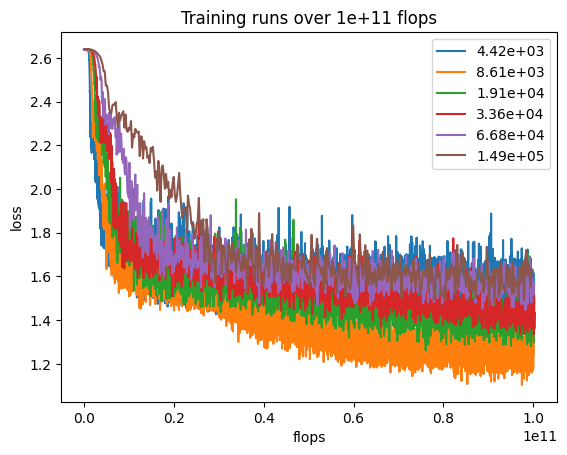

In [ ]:
FLOPS_HORIZON = 1e11
CHUNK_SIZE = 10
BS = 16
FLOPS_HORIZON = 1e11
preliminary_training_configs = build_training_configs(MODEL_CONFIGS, CHUNK_SIZE, BS, FLOPS_HORIZON)
losses = train_models(MODEL_CONFIGS, preliminary_training_configs)
plot_losses(MODEL_CONFIGS, preliminary_training_configs, losses, f_name=f'prelim_{FLOPS_HORIZON:1.0e}')

model size: 4.42e+03 training for flops: 1.00e+13 and steps: 1387600
model size: 8.61e+03 training for flops: 1.00e+13 and steps: 711900
model size: 1.91e+04 training for flops: 1.00e+13 and steps: 321600
model size: 3.36e+04 training for flops: 1.00e+13 and steps: 182400
model size: 6.68e+04 training for flops: 1.00e+13 and steps: 91800
model size: 1.49e+05 training for flops: 1.00e+13 and steps: 41100
--- starting run for model of size 4.42e+03 ---
step: 1000, loss: 2.637132167816162
step: 2000, loss: 2.3162200450897217
step: 3000, loss: 2.201467990875244
step: 4000, loss: 2.0322396755218506
step: 5000, loss: 1.982460379600525
step: 6000, loss: 1.809226155281067
step: 7000, loss: 1.9276710748672485
step: 8000, loss: 1.7536661624908447
step: 9000, loss: 1.679547905921936
step: 10000, loss: 1.6092827320098877
step: 11000, loss: 1.728966474533081
step: 12000, loss: 1.5958375930786133
step: 13000, loss: 1.6343538761138916
step: 14000, loss: 1.5979822874069214
step: 15000, loss: 1.5339493

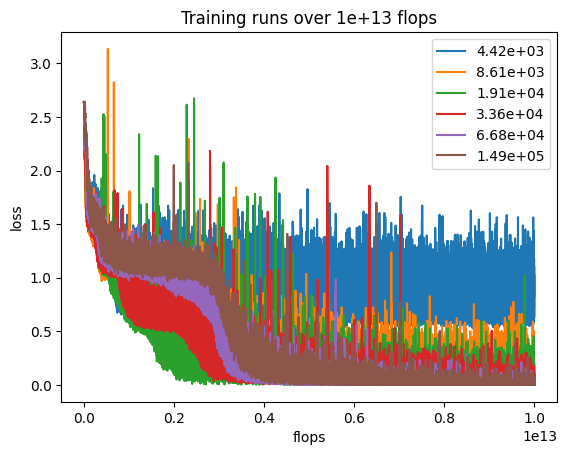

In [ ]:
FLOPS_HORIZON = 1e13
CHUNK_SIZE = 100
preliminary_training_configs = build_training_configs(MODEL_CONFIGS, CHUNK_SIZE, BS, FLOPS_HORIZON, 1000)
losses = train_models(MODEL_CONFIGS, preliminary_training_configs)
plot_losses(MODEL_CONFIGS, preliminary_training_configs, losses, f_name=f'prelim_{FLOPS_HORIZON:1.0e}')

## Create grid of runs to use for Chinchilla scaling law approaches

In [ ]:
# two decades of compute from 1e11 to 1e13
FLOP_HORIZONS = [int(1e11*(2.5119**i)) for i in range(6)]

for f in FLOP_HORIZONS:
    print(f'{f:1.2e}')


def build_grid_training_configs(model_configs, flop_horizons, chunk_size, bs, load_bal_alpha=0.0, max_lr=1e-3, min_lr=1e-4):
    return [
        build_training_configs(
            model_configs,
            chunk_size,
            bs,
            horizon,
            load_bal_alpha,
            print_every=1000,
            max_lr=max_lr,
            min_lr=min_lr
        )
        for horizon in flop_horizons
   ]


CHUNK_SIZE = 10
BS = 16
TRAINING_CONFIGS = build_grid_training_configs(
    MODEL_CONFIGS,
    FLOP_HORIZONS,
    CHUNK_SIZE,
    BS
)


# FLOP_HORIZONS x MODEL_CONFIGS
def train_grid(
        model_configs,
        training_configs,
        *,
        folder='grid'
):
    is_moe = bool(model_configs[0].moe_config)
    loss_grid = []
    ce_loss_grid = []
    aux_loss_grid = []
    for i in range(len(training_configs)):
        l = train_models(
            model_configs,
            training_configs[i],
            folder=folder
        )
        if is_moe:
            losses, ce_losses, aux_losses = l
            loss_grid.append(losses)
            ce_loss_grid.append(ce_losses)
            aux_loss_grid.append(aux_losses)
        else:
            loss_grid.append(l)

    if is_moe:
        return loss_grid, ce_loss_grid, aux_loss_grid
    return loss_grid

1.00e+11
2.51e+11
6.31e+11
1.58e+12
3.98e+12
1.00e+13
model size: 4.42e+03 training for flops: 1.00e+11 and steps: 13880
model size: 8.61e+03 training for flops: 1.00e+11 and steps: 7120
model size: 1.91e+04 training for flops: 1.00e+11 and steps: 3220
model size: 3.36e+04 training for flops: 1.00e+11 and steps: 1830
model size: 6.68e+04 training for flops: 1.00e+11 and steps: 920
model size: 1.49e+05 training for flops: 9.99e+10 and steps: 410
model size: 4.42e+03 training for flops: 2.51e+11 and steps: 34860
model size: 8.61e+03 training for flops: 2.51e+11 and steps: 17880
model size: 1.91e+04 training for flops: 2.51e+11 and steps: 8080
model size: 3.36e+04 training for flops: 2.51e+11 and steps: 4580
model size: 6.68e+04 training for flops: 2.52e+11 and steps: 2310
model size: 1.49e+05 training for flops: 2.53e+11 and steps: 1040
model size: 4.42e+03 training for flops: 6.31e+11 and steps: 87550
model size: 8.61e+03 training for flops: 6.31e+11 and steps: 44920
model size: 1.91e+0

In [ ]:
# compute loss grid from scratch
loss_grid = train_grid(MODEL_CONFIGS, TRAINING_CONFIGS)

In [ ]:
# load loss grid from disk
def load_loss_grid_from_disk(model_configs, training_configs, *, folder='grid'):
    loss_grid = []
    ce_loss_grid = []
    aux_loss_grid = []
    is_moe = bool(model_configs[0].moe_config)
    for ts in training_configs:
        losses_at_c = []
        ce_losses_at_c = []
        aux_losses_at_c = []
        for i in range(len(model_configs)):
            t = ts[i]
            m = model_configs[i]
            with open(folder + f'/size_{m.size():1.2e}_flops_{t.flops:1.2e}.npy', 'rb') as f:
                losses = np.load(f)
                assert losses.shape[0] == t.steps
                if is_moe:
                    ce_losses = np.load(f)
                    aux_losses = np.load(f)
                    ce_losses_at_c.append(ce_losses)
                    aux_losses_at_c.append(aux_losses)
                losses_at_c.append(losses)
        loss_grid.append(losses_at_c)
        ce_loss_grid.append(ce_losses_at_c)
        aux_loss_grid.append(aux_losses_at_c)
    if is_moe:
        return loss_grid, ce_loss_grid, aux_loss_grid
    return loss_grid

In [ ]:
loss_grid = load_loss_grid_from_disk(MODEL_CONFIGS, TRAINING_CONFIGS)

In [ ]:
import numpy as np

def gaussian_smooth(arr: np.ndarray, sigma):
    radius = int(3*sigma)
    inds = np.arange(-radius, radius+1)
    kernel = np.exp(-(inds**2)/(2*(sigma**2)))
    # symmetrical
    kernel = kernel / np.sum(kernel)
    padded_arr = np.pad(arr, (radius, radius), constant_values=(arr[0], arr[-1]))
    return np.convolve(padded_arr, kernel, mode='valid')


# visually verify gaussian smoothing window
# for h_i in range(len(TRAINING_CONFIGS)):
#     for m_i in range(2):
#         m = MODEL_CONFIGS[m_i]
#         t = TRAINING_CONFIGS[h_i][m_i]
#         losses = loss_grid[h_i][m_i]
#         sigma = t.steps // 100
#         smoothed_losses = gaussian_smooth(losses, sigma)
#         plot_losses([m], [t], [losses])
#         plot_losses([m], [t], [smoothed_losses], extra='smoothed')

In [ ]:
# smooth losses
def smooth_loss_grid(model_configs, training_configs, loss_grid):
    smoothed_loss_grid = []
    for ts_i in range(len(training_configs)):
        tmp = []
        for m_i in range(len(model_configs)):
            losses = loss_grid[ts_i][m_i]
            t = training_configs[ts_i][m_i]
            smoothed_losses = gaussian_smooth(losses, t.steps // 100)
            tmp.append(smoothed_losses)
        smoothed_loss_grid.append(tmp)
    return smoothed_loss_grid

In [ ]:
smoothed_loss_grid = smooth_loss_grid(MODEL_CONFIGS, TRAINING_CONFIGS, loss_grid)

In [ ]:
# exclude flop budgets that had multiple runs that saturated (ambiguous)
def filter_saturated_runs(model_configs, training_configs, flop_horizons, smoothed_loss_grid, thrsh=2e-2):
    smoothed_valid_loss_grid = []
    valid_training_configs = []
    valid_flop_horizons = []
    for ts_i in range(len(training_configs)):
        saturated_ct = 0
        for m_i in range(len(model_configs)):
            smoothed_losses = smoothed_loss_grid[ts_i][m_i]
            t = training_configs[ts_i][m_i]
            tail_window = smoothed_losses[-int(0.01*t.steps):]
            if np.median(tail_window) <= thrsh:
                saturated_ct += 1

        if saturated_ct <= 1:
            smoothed_valid_loss_grid.append(smoothed_loss_grid[ts_i])
            valid_training_configs.append(training_configs[ts_i])
            valid_flop_horizons.append(flop_horizons[ts_i])

    return smoothed_valid_loss_grid, valid_training_configs, valid_flop_horizons

In [ ]:
smoothed_valid_loss_grid, valid_training_configs, valid_flop_horizons = filter_saturated_runs(
    MODEL_CONFIGS,
    TRAINING_CONFIGS,
    FLOP_HORIZONS,
    smoothed_loss_grid
)


for f in valid_flop_horizons:
    print(f'VALID FLOP HORIZON: {f:1.2e}')

VALID FLOP HORIZON: 1.00e+11
VALID FLOP HORIZON: 2.51e+11
VALID FLOP HORIZON: 6.31e+11
VALID FLOP HORIZON: 1.58e+12
VALID FLOP HORIZON: 3.98e+12


## Chinchilla Laws (Dense Model) - Approach 1: Fix model sizes and vary number of training tokens

In [ ]:
class TrainingRunTailInterp:
    def __init__(self, model_size, bs, flops_range, smoothed_tail):
        self.model_size = model_size
        self.smoothed_tail = smoothed_tail
        self.flops_per_step = 6 * model_size * bs * MAX_SEQ_LEN
        self.flops_range = flops_range


    def covers(self, flops):
        return self.flops_range[0] <= flops <= self.flops_range[1]


    def interp_loss(self, flops):
        # get continuous mapping of C -> loss
        x = (np.arange(len(self.smoothed_tail)) * self.flops_per_step) + self.flops_range[0]
        return np.interp(flops, x, self.smoothed_tail)


def build_interpolants(model_configs, training_configs, smooth_loss_grid, tail_range=0.15):
    interpolants = []
    for ts_i in range(len(training_configs)):
        for m_i in range(len(model_configs)):
            m = model_configs[m_i]
            t = training_configs[ts_i][m_i]
            smooth_losses = smooth_loss_grid[ts_i][m_i]
            start_i = int(smooth_losses.shape[0]*(1-tail_range))
            flops_per_step = 6 * m.size() * t.bs * MAX_SEQ_LEN
            flops_range = (int(flops_per_step*start_i), t.flops)
            smoothed_tail = smooth_losses[start_i:]
            interpolants.append(
                TrainingRunTailInterp(
                    model_size=m.size(),
                    bs=t.bs,
                    flops_range=flops_range,
                    smoothed_tail=smoothed_tail
                )
            )

    return interpolants


@dataclass
class OptPoint:
    n_opt: int
    d_opt: int
    c: float


def fit_power_laws(opt_pts):
    ln_c = np.log(np.array([pt.c for pt in opt_pts])).reshape((-1, 1))
    x = np.hstack([ln_c, np.ones(ln_c.shape)])

    ln_n_opt = np.log(np.array([pt.n_opt for pt in opt_pts])).reshape((-1, 1))
    ln_d_opt = np.log(np.array([pt.d_opt for pt in opt_pts])).reshape((-1, 1))

    n_opt_params, _, _, _ = np.linalg.lstsq(x, ln_n_opt)
    n_opt_power, n_opt_coeff = n_opt_params[0], np.exp(n_opt_params[1])

    d_opt_params, _, _, _ = np.linalg.lstsq(x, ln_d_opt)
    d_opt_power, d_opt_coeff = d_opt_params[0], np.exp(d_opt_params[1])

    return n_opt_power, n_opt_coeff, d_opt_power, d_opt_coeff



def fit_power_laws_approach_1(valid_model_configs, valid_training_configs, valid_smooth_loss_grid, log_c_range):
    interpolants = build_interpolants(valid_model_configs, valid_training_configs, valid_smooth_loss_grid)
    global_min = float(min([i.flops_range[0] for i in interpolants]))
    global_max = float(max([i.flops_range[1] for i in interpolants]))
    p = (global_max/global_min)**(1/log_c_range)
    log_spaced_c = global_min * (p**np.arange(1, log_c_range+1))

    # find optimal points
    opt_pts = []
    for c in log_spaced_c:
        min_loss = float('inf')
        min_interpolant = None
        for i in interpolants:
            if i.covers(c):
                i_loss = i.interp_loss(c)
                if i_loss < min_loss:
                    min_loss = i_loss
                    min_interpolant = i

        if min_interpolant:
            n_opt = min_interpolant.model_size
            d_opt = c / (6 * n_opt)
            opt_pts.append(OptPoint(n_opt=n_opt, d_opt=d_opt, c=c))

    return fit_power_laws(opt_pts)


In [ ]:
n_opt_power, n_opt_coeff, d_opt_power, d_opt_coeff = fit_power_laws_approach_1(
    MODEL_CONFIGS,
    valid_training_configs,
    smoothed_valid_loss_grid,
    350
)

print('Approach 1 results:')
print(f'N_opt power: {n_opt_power}, coeff: {n_opt_coeff}')
print(f'D_opt power: {d_opt_power}, coeff: {d_opt_coeff}')

Approach 1 results:
N_opt power: [-0.0183616], coeff: [14694.6218184]
D_opt power: [1.0183616], coeff: [1.13420181e-05]


## Approach 2: IsoFLOP profiles

In [ ]:
import numpy as np

def fit_power_laws_approach_2(valid_model_configs, valid_flop_horizons, valid_smooth_loss_grid):
    n = np.array([m.size() for m in valid_model_configs])

    final_losses = np.hstack([
        np.array([np.median(l[-int(0.01*l.shape[0]):]) for l in ls]).reshape((-1, 1))
        for ls in valid_smooth_loss_grid
    ])
    polys = np.polyfit(np.log(n), final_losses, 2)

    cmap = plt.get_cmap('viridis')
    colors = cmap(np.linspace(0, 1, len(valid_smooth_loss_grid)))

    # plot parabolas
    fig, ax = plt.subplots()
    for i in range(len(valid_flop_horizons)):
        f = valid_flop_horizons[i]
        color = colors[i]
        final_l = final_losses[:, i].flatten()
        # plot regular points
        ax.plot(n, final_l, 'o', color=color, label=f'{f:1.0e}')
        # plot fitted polynomials
        p = polys[:, i].flatten()
        x = np.linspace(np.log(n.min()), np.log(n.max()), 150)
        ax.plot(np.exp(x), np.polyval(p, x), '--', color=color)

    ax.set_xscale('log')
    ax.set_xlabel('parameters')
    ax.set_ylabel('loss')
    ax.set_title('IsoFLOP curves')
    ax.legend()

    A = polys[0]
    B = polys[1]
    n_opts = np.exp(-B/(2*A))
    opt_pts = []
    for i in range(len(n_opts)):
        c = valid_flop_horizons[i]
        n_opt = n_opts[i]
        d_opt = c / (6 * n_opt)
        opt_pts.append(OptPoint(n_opt=int(n_opt), d_opt=int(d_opt), c=int(c)))

    return fit_power_laws(opt_pts)


Approach 2 results:
N_opt power: [-0.0393276], coeff: [49602.70201959]
D_opt power: [1.03931385], coeff: [3.36119794e-06]


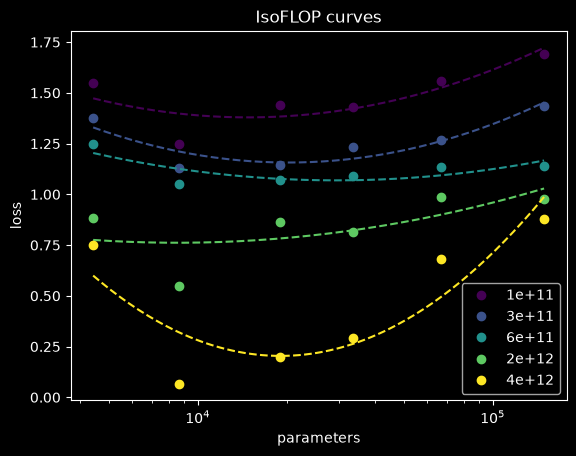

In [ ]:
n_opt_power, n_opt_coeff, d_opt_power, d_opt_coeff = fit_power_laws_approach_2(
    MODEL_CONFIGS,
    valid_flop_horizons,
    smoothed_valid_loss_grid,
)

print('Approach 2 results:')
print(f'N_opt power: {n_opt_power}, coeff: {n_opt_coeff}')
print(f'D_opt power: {d_opt_power}, coeff: {d_opt_coeff}')


## Approach 3: Fitting a parametric loss function

In [ ]:
import itertools


def fit_power_laws_approach_3(model_configs, valid_training_configs, valid_flop_horizons, smoothed_valid_loss_grid):
    # run L-BFGS algorithm to fit initial loss function
    def run_lbfgs_opt(init_params, f, opt, max_iter, tol):
        value_and_grad_f = optax.value_and_grad_from_state(f)
        def step(carry):
            params, state = carry
            value, grad = value_and_grad_f(params, state=state)
            updates, state = opt.update(
                grad, state, params, value=value, grad=grad, value_fn=f
            )
            params = optax.apply_updates(params, updates)
            return params, state

        # use grad tol for stopping condition
        def continue_criterion(carry):
            _, state = carry
            iter = optax.tree.get(state, 'count')
            grad = optax.tree.get(state, 'grad')
            err = optax.tree.norm(grad)
            return (iter == 0) | ((iter < max_iter) & (err >= tol))

        init_carry = (init_params, opt.init(init_params))
        final_params, _ = jax.lax.while_loop(continue_criterion, step, init_carry)
        return final_params

    ns = []
    ds = []
    ls = []
    for ts_i in range(len(valid_training_configs)):
        for m_i in range(len(model_configs)):
            flops = valid_flop_horizons[ts_i]
            n = model_configs[m_i].size()
            d = flops / (6 * n)
            smoothed_losses = smoothed_valid_loss_grid[ts_i][m_i]
            final_loss = jnp.median(smoothed_losses[-int(0.01*smoothed_losses.shape[0]):])
            ns.append(n)
            ds.append(d)
            ls.append(final_loss)

    ns = jnp.array(ns)
    ds = jnp.array(ds)
    ls = jnp.array(ls)

    # e = params[0], a = params[1], b = params[2], alpha = params[3], beta = params[4]
    # ns: [N, ], ds: [N, ]
    # returns log of loss already
    def log_loss_model(params, ns, ds):
        e, a, b, alpha, beta = params
        op1 = a - alpha*jnp.log(ns)
        op2 = b - beta*jnp.log(ds)
        e = jnp.broadcast_to(e, ns.shape)
        return jax.nn.logsumexp(jnp.vstack([op1, op2, e]), axis=0)

    def fit_loss(params):
        diff = log_loss_model(params, ns, ds) - jnp.log(ls)
        return jnp.sum(optax.huber_loss(diff, delta=1e-3))

    # try grid of initializations for best fit
    alpha_grid = [0, 0.5, 1, 1.5, 2]
    beta_grid = [0, 0.5, 1, 1.5, 2]
    e_grid = [-1, -0.5, 0, 0.5, 1]
    a_grid = [0, 5, 10, 15, 20, 25]
    b_grid = [0, 5, 10, 15, 20, 25]

    init_params_grid = itertools.product(e_grid, a_grid, b_grid, alpha_grid, beta_grid)
    init_params_grid = jnp.vstack([jnp.array(i) for i in init_params_grid])

    def fit_loss_model_from_init_param(init_params):
        opt = optax.lbfgs()
        final_params = run_lbfgs_opt(init_params, fit_loss, opt, max_iter=200, tol=1e-3)
        return final_params, fit_loss(final_params)

    final_params_grid, final_params_losses = jax.vmap(fit_loss_model_from_init_param)(init_params_grid)
    # mask out nans from final loss
    final_params_losses = jnp.where(jnp.isnan(final_params_losses), jnp.float32('inf'), final_params_losses)
    min_loss_i = jnp.argmin(final_params_losses)
    min_loss = final_params_losses[min_loss_i]
    min_params = final_params_grid[min_loss_i]

    e_opt, a_opt, b_opt, alpha_opt, beta_opt = min_params
    A_opt, B_opt, E_opt = jnp.exp(a_opt), jnp.exp(b_opt), jnp.exp(e_opt)
    G = ((alpha_opt * A_opt) / (beta_opt * B_opt)) ** (1/(alpha_opt + beta_opt))
    n_opt_power = beta_opt / (alpha_opt + beta_opt)
    d_opt_power = alpha_opt / (alpha_opt + beta_opt)

    return G, n_opt_power, d_opt_power




In [ ]:
G, n_opt_power, d_opt_power = fit_power_laws_approach_3(MODEL_CONFIGS, valid_training_configs, valid_flop_horizons, smoothed_valid_loss_grid)

print('Approach 3 results:')
print(f'N_opt power: {n_opt_power}')
print(f'D_opt power: {d_opt_power}')

Approach 3 results:
N_opt power: 0.1539660096168518
D_opt power: 0.8460339903831482


## Chinchilla Laws (MoE version)

In [ ]:
MOE_MODEL_CONFIGS = [
    # 4.4K
    ModelConfig(
        hidden_size=16,
        ffw_size=4*16,
        layers=1,
        attn_heads=4,
        vocab_size=14,
        moe_config=MoEConfig(
            experts=4,
            experts_per_token=1,
        )
    ),

    # 8K
    ModelConfig(
        hidden_size=16,
        ffw_size=4*16,
        layers=2,
        attn_heads=4,
        vocab_size=14,
        moe_config=MoEConfig(
            experts=4,
            experts_per_token=1
        )
    ),

    # ~19K
    ModelConfig(
        hidden_size=24,
        ffw_size=4*24,
        layers=2,
        attn_heads=4,
        vocab_size=14,
        moe_config=MoEConfig(
            experts=4,
            experts_per_token=1
        )
    ),

    # 33.6K
    ModelConfig(
        hidden_size=32,
        ffw_size=4*32,
        layers=2,
        attn_heads=4,
        vocab_size=14,
        moe_config=MoEConfig(
            experts=4,
            experts_per_token=1
        )
    ),

    # 66.8K
    ModelConfig(
        hidden_size=32,
        ffw_size=4*32,
        layers=4,
        attn_heads=4,
        vocab_size=14,
        moe_config=MoEConfig(
            experts=4,
            experts_per_token=1
        )
    ),

    # ~150K
    ModelConfig(
        hidden_size=48,
        ffw_size=4*48,
        layers=4,
        attn_heads=4,
        vocab_size=14,
        moe_config=MoEConfig(
            experts=4,
            experts_per_token=1
        )
    ),
]

MOE_TRAINING_CONFIGS = build_grid_training_configs(
    MOE_MODEL_CONFIGS,
    FLOP_HORIZONS,
    CHUNK_SIZE,
    BS,
    load_bal_alpha=1e-2,
)

model size: 4.42e+03 training for flops: 1.00e+11 and steps: 13880
model size: 8.61e+03 training for flops: 1.00e+11 and steps: 7120
model size: 1.91e+04 training for flops: 1.00e+11 and steps: 3220
model size: 3.36e+04 training for flops: 1.00e+11 and steps: 1830
model size: 6.68e+04 training for flops: 1.00e+11 and steps: 920
model size: 1.49e+05 training for flops: 9.99e+10 and steps: 410
model size: 4.42e+03 training for flops: 2.51e+11 and steps: 34860
model size: 8.61e+03 training for flops: 2.51e+11 and steps: 17880
model size: 1.91e+04 training for flops: 2.51e+11 and steps: 8080
model size: 3.36e+04 training for flops: 2.51e+11 and steps: 4580
model size: 6.68e+04 training for flops: 2.52e+11 and steps: 2310
model size: 1.49e+05 training for flops: 2.53e+11 and steps: 1040
model size: 4.42e+03 training for flops: 6.31e+11 and steps: 87550
model size: 8.61e+03 training for flops: 6.31e+11 and steps: 44920
model size: 1.91e+04 training for flops: 6.31e+11 and steps: 20290
model 

In [ ]:
# compute loss grid from scratch
moe_loss_grid, moe_ce_loss_grid, moe_aux_loss_grid = train_grid(MOE_MODEL_CONFIGS, MOE_TRAINING_CONFIGS, folder='moe_grid')

In [ ]:
moe_loss_grid, moe_ce_loss_grid, moe_aux_loss_grid = load_loss_grid_from_disk(MOE_MODEL_CONFIGS, MOE_TRAINING_CONFIGS, folder='moe_grid')

In [ ]:
smoothed_moe_ce_loss_grid = smooth_loss_grid(MOE_MODEL_CONFIGS, MOE_TRAINING_CONFIGS, moe_loss_grid)
smoothed_valid_moe_ce_loss_grid, valid_moe_training_configs, valid_moe_flop_horizons = filter_saturated_runs(
    MOE_MODEL_CONFIGS,
    MOE_TRAINING_CONFIGS,
    FLOP_HORIZONS,
    smoothed_moe_ce_loss_grid,
    thrsh=2e-2
)

for f in valid_moe_flop_horizons:
    print(f'VALID FLOP HORIZON: {f:1.2e}')


VALID FLOP HORIZON: 1.00e+11
VALID FLOP HORIZON: 2.51e+11
VALID FLOP HORIZON: 6.31e+11
VALID FLOP HORIZON: 1.58e+12
VALID FLOP HORIZON: 3.98e+12
VALID FLOP HORIZON: 1.00e+13


In [ ]:
# approach 1
moe_n_opt_power, moe_n_opt_coeff, moe_d_opt_power, moe_d_opt_coeff = fit_power_laws_approach_1(
    MOE_MODEL_CONFIGS,
    valid_moe_training_configs,
    smoothed_valid_moe_ce_loss_grid,
    350
)

print('Approach 1 results:')
print(f'N_opt power: {moe_n_opt_power}, coeff: {moe_n_opt_coeff}')
print(f'D_opt power: {moe_d_opt_power}, coeff: {moe_d_opt_coeff}')

Approach 1 results:
N_opt power: [0.10538593], coeff: [707.27234205]
D_opt power: [0.89461407], coeff: [0.00023565]


Approach 2 results:
N_opt power: [0.98953244], coeff: [6.30691651e-08]
D_opt power: [0.0104742], coeff: [2642034.48027779]


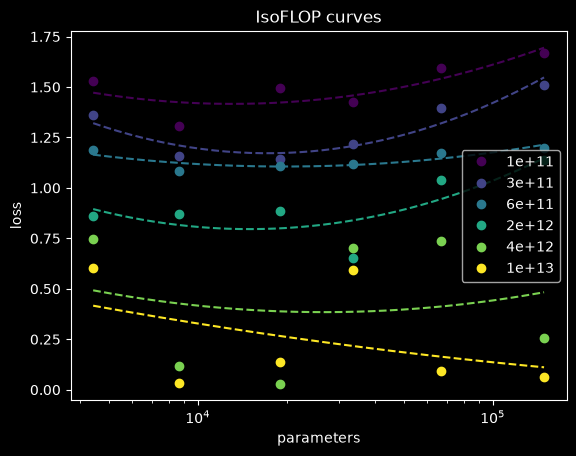

In [ ]:
# approach 2
moe_n_opt_power, moe_n_opt_coeff, moe_d_opt_power, moe_d_opt_coeff = fit_power_laws_approach_2(
    MOE_MODEL_CONFIGS,
    valid_moe_flop_horizons,
    smoothed_valid_moe_ce_loss_grid,
)

print('Approach 2 results:')
print(f'N_opt power: {moe_n_opt_power}, coeff: {moe_n_opt_coeff}')
print(f'D_opt power: {moe_d_opt_power}, coeff: {moe_d_opt_coeff}')

In [ ]:
# approach 3
moe_G, moe_n_opt_power, moe_d_opt_power = fit_power_laws_approach_3(
    MOE_MODEL_CONFIGS,
    valid_moe_training_configs,
    valid_moe_flop_horizons,
    smoothed_valid_moe_ce_loss_grid
)

print('Approach 3 results:')
print(f'N_opt power: {moe_n_opt_power}')
print(f'D_opt power: {moe_d_opt_power}')

Approach 3 results:
N_opt power: 0.25089994072914124
D_opt power: 0.7491000890731812


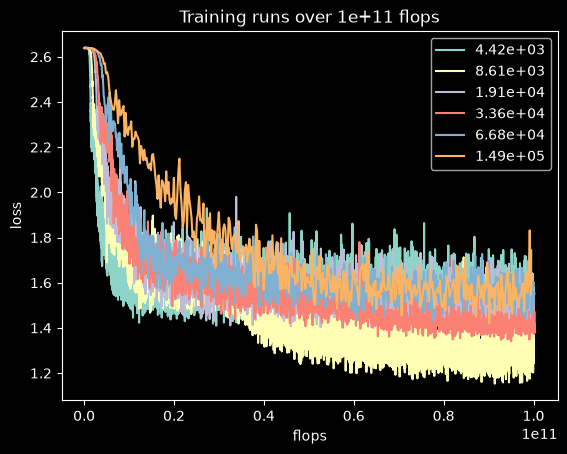

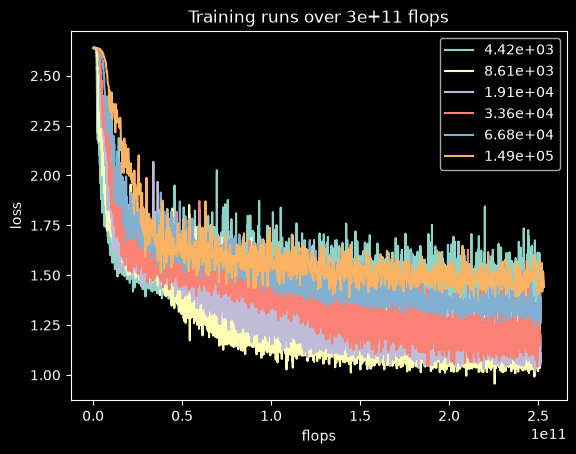

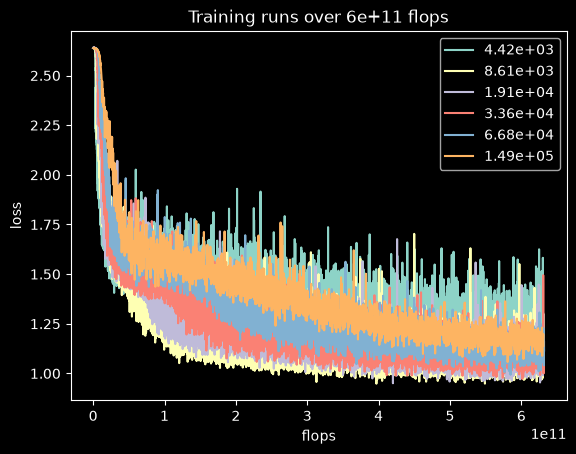

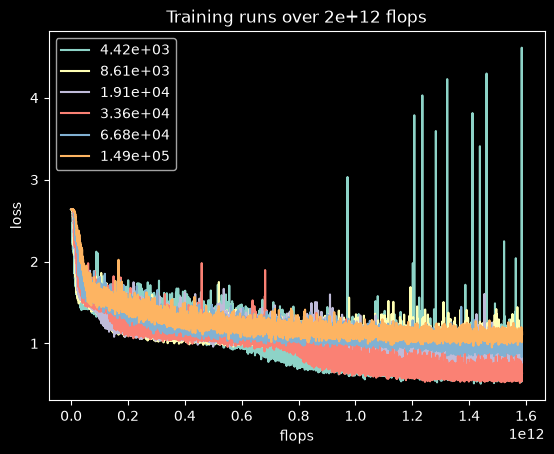

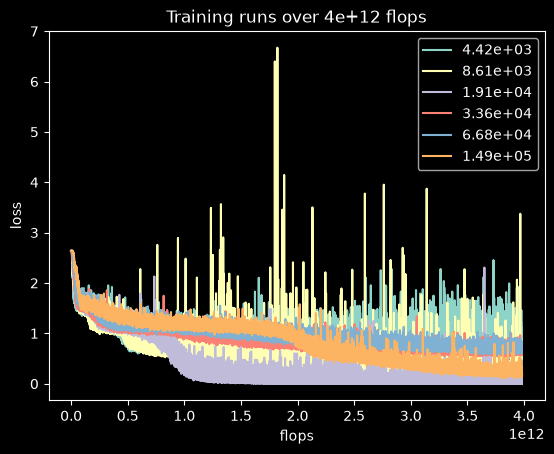

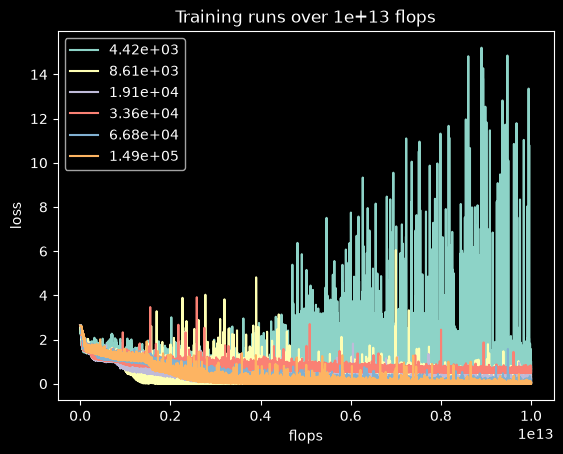

In [ ]:
for i in range(len(MOE_TRAINING_CONFIGS)):
    ts = MOE_TRAINING_CONFIGS[i]
    losses = moe_ce_loss_grid[i]
    plot_losses(MOE_MODEL_CONFIGS, ts, losses)

## Train 10M param MoE and dense models

In [ ]:
from dataclasses import replace


DENSE_10M_MODEL_CONFIG = ModelConfig(
    hidden_size=256,
    ffw_size=4*256,
    layers=10,
    attn_heads=4,
    vocab_size=14,
    moe_config=None
)

MOE_10M_MODEL_CONFIG = ModelConfig(
    hidden_size=224,
    ffw_size=4*224,
    layers=8,
    attn_heads=4,
    vocab_size=14,
    moe_config=MoEConfig(
        experts_per_token=2,
        experts=4
    )
)


bs = 32
chunk_size = 1000
steps = 100_000
flops = int(6 * DENSE_10M_MODEL_CONFIG.size() * bs * MAX_SEQ_LEN * steps)
TRAINING_CONFIG_10M_DENSE = TrainingConfig(
    max_lr=1e-3,
    min_lr=1e-4,
    steps=steps,
    flops=flops,
    warmup_steps=int(0.1*steps),
    bs=bs,
    seed=42,
    chunk_size=chunk_size,
    print_every=1000,
    load_bal_alpha=0
)
TRAINING_CONFIG_10M_MOE = replace(TRAINING_CONFIG_10M_DENSE, load_bal_alpha=1e-2)

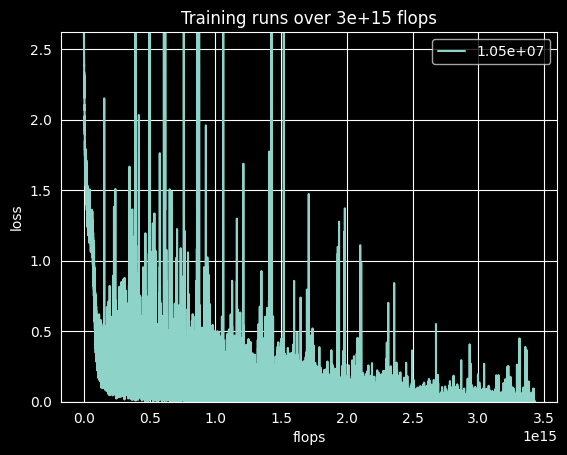

In [ ]:
import numpy as np

dense_losses = train_model(DENSE_10M_MODEL_CONFIG, TRAINING_CONFIG_10M_DENSE)
plot_losses([DENSE_10M_MODEL_CONFIG], [TRAINING_CONFIG_10M_DENSE], [dense_losses], f_name='10M_dense')

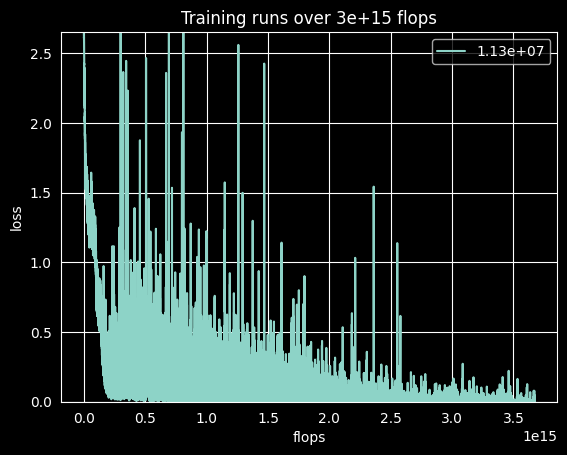

In [ ]:
moe_losses, ce_losses, aux_losses = train_model(MOE_10M_MODEL_CONFIG, TRAINING_CONFIG_10M_MOE)
plot_losses([MOE_10M_MODEL_CONFIG], [TRAINING_CONFIG_10M_MOE], [ce_losses], f_name='10M_moe')

## Fuse the mlp layer of the MoE version

In the forward pass, in the domain where B is large compared to D, F - the AI of the unfused operation ~= D/b where b is the dtype precision. At float32 and on a tpu v5e, the unfused version at D=256 is memory bound compared to the fused version which has an AI of F. In this regime the largest speedup happens.

In the backwards pass, the unfused version is basically always memory bound due to the large [B, F] intermediates. There is a large speedup in training step => higher throughput.


In [4]:
from jax.experimental import pallas as pl
from jax.experimental.pallas import tpu as pltpu
import functools


def pad_tokens_by_block_size(sorted_flat_x, sizes, bb):
    B, D = sorted_flat_x.shape
    E = sizes.shape[0]
    num_tiles = (B + (E+1)*(bb-1)) // bb
    out = jnp.zeros((num_tiles*bb, D))
    padded_sizes = -bb * (-sizes // bb)
    offs = jnp.concat([jnp.array([0]), jnp.cumsum(sizes)])[:-1]
    padded_offs = jnp.concat([jnp.array([0]), jnp.cumsum(padded_sizes)])[:-1]
    inds = jnp.repeat(padded_offs, sizes, total_repeat_length=B)
    inds_offs = jnp.arange(B) - jnp.repeat(offs, sizes, total_repeat_length=B)
    inds = inds + inds_offs
    out = out.at[inds].set(sorted_flat_x)
    tile_experts = jnp.repeat(jnp.arange(E), padded_sizes // bb, total_repeat_length=num_tiles)
    return out, tile_experts, inds


def fused_swiglu_fwd_kernel(tile_exp_ref, x_ref, up_proj1_ref, up_proj2_ref, beta_ref, down_proj_ref, out_ref):
    @pl.when(pl.program_id(1) == 0)
    def _():
        out_ref[...] = jnp.zeros_like(out_ref)

    f1 = x_ref[...] @ up_proj1_ref[...]
    f2 = x_ref[...] @ up_proj2_ref[...]
    swiglu_out = f1 * f2 * jax.nn.sigmoid(beta_ref[...] * f2)
    out_ref[...] += swiglu_out @ down_proj_ref[...]


def fused_swiglu_fwd(psf_x, tile_experts, up_proj1, up_proj2, beta, down_proj, bb=256, bf=256):
    E, D, F = up_proj1.shape
    b, _ = psf_x.shape
    return pl.pallas_call(
        fused_swiglu_fwd_kernel,
        out_shape=jax.ShapeDtypeStruct((b, D), psf_x.dtype),
        grid_spec=pltpu.PrefetchScalarGridSpec(
            num_scalar_prefetch=1,
            grid=(b//bb, F//bf),
            in_specs=[
                pl.BlockSpec((bb, D), lambda b_i, f_i, te: (b_i, 0)),
                pl.BlockSpec((None, D, bf), lambda b_i, f_i, te: (te[b_i], 0, f_i)),
                pl.BlockSpec((None, D, bf), lambda b_i, f_i, te: (te[b_i], 0, f_i)),
                pl.BlockSpec((bf,), lambda b_i, f_i, e: (f_i,)),
                pl.BlockSpec((None, bf, D), lambda b_i, f_i, te: (te[b_i], f_i, 0))
            ],
            out_specs=pl.BlockSpec((bb, D), lambda b_i, f_i, te: (b_i, 0)),
        ),
        compiler_params=pltpu.CompilerParams(
            dimension_semantics=('parallel', 'arbitrary')
        )
    )(tile_experts, psf_x, up_proj1, up_proj2, beta, down_proj)


@functools.partial(jax.custom_vjp, nondiff_argnums=(6, 7, 8))
def fused_swiglu(psf_x, tile_experts, up_proj1, up_proj2, beta, down_proj, bb=256, bf=256, bwd_bf=256):
    return fused_swiglu_fwd(psf_x, tile_experts, up_proj1, up_proj2, beta, down_proj, bb=bb, bf=bf)


def _fused_swiglu_fwd(psf_x, tile_experts, up_proj1, up_proj2, beta, down_proj, bb=256, bf=256, bwd_bf=256):
    out = fused_swiglu_fwd(psf_x, tile_experts, up_proj1, up_proj2, beta, down_proj, bb=bb, bf=bf)
    res = (psf_x, tile_experts, up_proj1, up_proj2, beta, down_proj)
    return out, res


def fused_swiglu_bwd_kernel(
        te_ref,
        psf_x_ref,
        up_proj1_ref,
        up_proj2_ref,
        beta_ref,
        down_proj_ref,
        dout_ref,
        # input aliases (unused)
        _ddown_proj_in_ref,
        _dup_proj1_in_ref,
        _dup_proj2_in_ref,
        # output refs
        ddown_proj_ref,
        dbeta_ref,
        dup_proj1_ref,
        dup_proj2_ref,
        dx_ref, # full sized [b, D] acc
        # scratchpads
        ddown_proj_acc,
        dup_proj1_acc,
        dup_proj2_acc,
        dx_acc,
        *,
        bb
):
    # zero acc if last tile was routed to a different expert
    b_i = pl.program_id(1)
    f_i = pl.program_id(0)
    prev_e = te_ref[jnp.maximum(0, b_i - 1)]
    cur_e = te_ref[b_i]
    @pl.when((b_i == 0) | (prev_e != cur_e))
    def _():
        ddown_proj_acc[...] = jnp.zeros_like(ddown_proj_acc)
        dup_proj1_acc[...] = jnp.zeros_like(dup_proj1_acc)
        dup_proj2_acc[...] = jnp.zeros_like(dup_proj2_acc)

    @pl.when(b_i == 0)
    def _():
        dbeta_ref[...] = jnp.zeros_like(dbeta_ref)

    @pl.when((b_i == 0) & (f_i == 0))
    def _():
        dx_acc[...] = jnp.zeros_like(dx_acc)

    # recompute fwd pass tiles
    t1_3 = psf_x_ref[...] @ up_proj2_ref[...]
    t1_2 = beta_ref[...] * t1_3
    t1_1 = jax.nn.sigmoid(t1_2)
    t1 = t1_1 * t1_3
    t2 = psf_x_ref[...] @ up_proj1_ref[...]
    t = t1 * t2

    # bwd tiles
    ddown_proj_acc[...] += jax.lax.dot_general(
        t, dout_ref[...], (((0,), (0,)), ((), ())), preferred_element_type=jnp.float32
    )
    dt = jax.lax.dot_general(
        dout_ref[...], down_proj_ref[...], (((1,), (1,)), ((), ())), preferred_element_type=jnp.float32
    )
    dt1 = dt * t2
    dt2 = dt * t1
    dt1_1 = dt1 * t1_3
    dt1_2 = dt1_1 * t1_1 * (1 - t1_1)
    dt1_3 = (dt1 * t1_1) + (beta_ref[...] * dt1_2)
    dbeta_ref[...] += jnp.sum(dt1_2 * t1_3, axis=0)
    dup_proj2_acc[...] += jax.lax.dot_general(
        psf_x_ref[...], dt1_3, (((0,), (0,)), ((), ())), preferred_element_type=jnp.float32
    )
    dup_proj1_acc[...] += jax.lax.dot_general(
        psf_x_ref[...], dt2, (((0,), (0,)), ((), ())), preferred_element_type=jnp.float32
    )
    dx_tmp1 = jax.lax.dot_general(
        dt1_3, up_proj2_ref[...], (((1,), (1,)), ((), ())), preferred_element_type=jnp.float32
    )
    dx_tmp2 = jax.lax.dot_general(
        dt2, up_proj1_ref[...], (((1,), (1,)), ((), ())), preferred_element_type=jnp.float32
    )

    sb = pl.program_id(1) * bb
    dx_acc[pl.ds(sb, bb), :] += dx_tmp1 + dx_tmp2

    last_b_i = pl.num_programs(1) - 1
    last_f_i = pl.num_programs(0) - 1
    next_e = te_ref[jnp.minimum(b_i + 1, last_b_i)]
    # save accs when moving onto next
    @pl.when((b_i == last_b_i) | (next_e != cur_e))
    def _():
        ddown_proj_ref[...] = ddown_proj_acc[...]
        dup_proj1_ref[...] = dup_proj1_acc[...]
        dup_proj2_ref[...] = dup_proj2_acc[...]

    @pl.when(f_i == last_f_i)
    def _():
        dx_ref[...] = dx_acc[pl.ds(sb, bb), :]


def _fused_swiglu_bwd(bb, bf, bwd_bf, res, dout):
    psf_x, tile_experts, up_proj1, up_proj2, beta, down_proj = res
    E, F, D = down_proj.shape
    b, _ = psf_x.shape
    ddown_proj = jnp.zeros((E, F, D), dtype=down_proj.dtype)
    dup_proj1 = jnp.zeros((E, D, F), dtype=up_proj1.dtype)
    dup_proj2 = jnp.zeros((E, D, F), dtype=up_proj2.dtype)
    ddown_proj, dbeta, dup_proj1, dup_proj2, dx = pl.pallas_call(
        functools.partial(fused_swiglu_bwd_kernel, bb=bb),
        grid_spec=pltpu.PrefetchScalarGridSpec(
            num_scalar_prefetch=1,
            in_specs=[
                pl.BlockSpec((bb, D), lambda f_i, b_i, te: (b_i, 0)),
                pl.BlockSpec((None, D, bwd_bf), lambda f_i, b_i, te: (te[b_i], 0, f_i)),
                pl.BlockSpec((None, D, bwd_bf), lambda f_i, b_i, te: (te[b_i], 0, f_i)),
                pl.BlockSpec((bwd_bf,), lambda f_i, b_i, te: (f_i,)),
                pl.BlockSpec((None, bwd_bf, D), lambda f_i, b_i, te: (te[b_i], f_i, 0)),
                pl.BlockSpec((bb, D), lambda f_i, b_i, te: (b_i, 0)),
                pl.BlockSpec((None, bwd_bf, D), lambda f_i, b_i, te: (te[b_i], f_i, 0)),
                pl.BlockSpec((None, D, bwd_bf), lambda f_i, b_i, te: (te[b_i], 0, f_i)),
                pl.BlockSpec((None, D, bwd_bf), lambda f_i, b_i, te: (te[b_i], 0, f_i)),
            ],
            out_specs=(
                pl.BlockSpec((None, bwd_bf, D), lambda f_i, b_i, te: (te[b_i], f_i, 0)),
                pl.BlockSpec((bwd_bf,), lambda f_i, b_i, te: (f_i,)),
                pl.BlockSpec((None, D, bwd_bf), lambda f_i, b_i, te: (te[b_i], 0, f_i)),
                pl.BlockSpec((None, D, bwd_bf), lambda f_i, b_i, te: (te[b_i], 0, f_i)),
                pl.BlockSpec((bb, D), lambda f_i, b_i, te: (b_i, 0))
            ),
            scratch_shapes=[
                pltpu.VMEM((bwd_bf, D), jnp.float32),
                pltpu.VMEM((D, bwd_bf), jnp.float32),
                pltpu.VMEM((D, bwd_bf), jnp.float32),
                pltpu.VMEM((b, D), jnp.float32)
            ],
            grid=(F//bwd_bf, b//bb)
        ),
        out_shape=(
            jax.ShapeDtypeStruct(ddown_proj.shape, ddown_proj.dtype),
            jax.ShapeDtypeStruct(beta.shape, beta.dtype),
            jax.ShapeDtypeStruct(up_proj1.shape, up_proj1.dtype),
            jax.ShapeDtypeStruct(up_proj2.shape, dtype=up_proj2.dtype),
            jax.ShapeDtypeStruct(psf_x.shape, psf_x.dtype)
        ),
        input_output_aliases={7:0, 8:2, 9:3},
        compiler_params=pltpu.CompilerParams(
            dimension_semantics=('arbitrary', 'arbitrary'),
            vmem_limit_bytes=int(100e6),
        )
    )(tile_experts, psf_x, up_proj1, up_proj2, beta, down_proj, dout, ddown_proj, dup_proj1, dup_proj2)

    return dx, None, dup_proj1, dup_proj2, dbeta, ddown_proj


fused_swiglu.defvjp(_fused_swiglu_fwd, _fused_swiglu_bwd)


def fused_mlp_swiglu(x_norm, up_proj1, up_proj2, beta, down_proj, top_k, bb=256, bf=256, bwd_bf=256):
    assert up_proj1.shape[2] % bf == 0 and up_proj1.shape[2] % bwd_bf == 0
    B, T, D = x_norm.shape
    _, _, k = top_k.shape
    E, _, F = up_proj1.shape
    flattened_x = x_norm.reshape((B*T, D))
    flattened_x_inds_padded = jnp.repeat(jnp.arange(B*T)[:, None], k, axis=-1)
    flattened_x_inds_padded = flattened_x_inds_padded.reshape((B*T*k,))
    flattened_routed_experts = top_k.reshape((B*T*k,))
    sorted_routed_experts_inds = jnp.argsort(flattened_routed_experts)
    sizes = jnp.bincount(flattened_routed_experts, minlength=E, length=E)
    sorted_flattened_x_inds = flattened_x_inds_padded[sorted_routed_experts_inds]
    sorted_flat_x = flattened_x[sorted_flattened_x_inds]
    padded_sorted_flat_x, tile_experts, real_token_inds = pad_tokens_by_block_size(sorted_flat_x, sizes, bb)

    out = fused_swiglu(padded_sorted_flat_x, tile_experts, up_proj1, up_proj2, beta, down_proj, bb, bf, bwd_bf)
    unpadded_out = out.at[real_token_inds].get()
    unpadded_out = jnp.zeros((B*T*k, D), dtype=out.dtype).at[sorted_routed_experts_inds].set(unpadded_out)
    return unpadded_out.reshape((B, T, k, D))


class Fused_MoE_MLP(nnx.Module):
    def __init__(self, config, *, bb, bf, bwd_bf, rngs):
        assert config.moe_config is not None
        self.config = config
        self.bb = bb
        self.bf = bf
        self.bwd_bf = bwd_bf
        hidden_size = config.hidden_size
        ffw_size = config.ffw_size
        moe_config = config.moe_config
        self.pre_norm = RMSNorm(config)
        E, k = moe_config.experts, moe_config.experts_per_token
        self.router = nnx.Param(0.02 * jax.random.normal(rngs.params(), (hidden_size, E)))
        self.glu_proj1 = nnx.Param(0.02 * jax.random.normal(rngs.params(), (E, hidden_size, ffw_size)))
        self.glu_proj2 = nnx.Param(0.02 * jax.random.normal(rngs.params(), (E, hidden_size, ffw_size)))
        self.down_proj = nnx.Param(0.02 * jax.random.normal(rngs.params(), (E, ffw_size, hidden_size)))
        self.beta = nnx.Param(jnp.ones(ffw_size))


    def __call__(self, x):
        t = self.pre_norm(x)
        moe_config = self.config.moe_config
        B, T, D = t.shape
        k, E = moe_config.experts_per_token, moe_config.experts
        router_logits = jnp.einsum('btd,de->bte', t, self.router)
        router_weights = jax.nn.softmax(router_logits, axis=-1)
        top_k_weights, top_k_experts = jax.lax.top_k(router_weights, k)
        swiglu_out = fused_mlp_swiglu(
            t, self.glu_proj1[...],
            self.glu_proj2[...],
            self.beta[...],
            self.down_proj[...],
            top_k=top_k_experts,
            bb=self.bb,
            bf=self.bf,
            bwd_bf=self.bwd_bf
        )
        out = jnp.sum(top_k_weights[..., None] * swiglu_out, axis=2)

        # common-subexpression elimination below - shouldn't be recomputed by XLA
        total = B * T
        sizes = jnp.bincount(top_k_experts.flatten(), minlength=E, length=E)
        f = sizes / total
        p = jnp.sum(router_weights, axis=[0, 1]) / total
        return x + out, p, f



In [7]:
import timeit
import jax, jax.numpy as jnp
from flax import nnx

def _share_weights(baseline, fused):
    fused.router = baseline.router
    fused.pre_norm.gamma = baseline.pre_norm.gamma
    fused.glu_proj1 = baseline.glu_proj1
    fused.glu_proj2 = baseline.glu_proj2
    fused.beta = baseline.beta
    fused.down_proj = baseline.down_proj

def verify(config, *, bb=256, bf=256, seed=0, atol=1e-3):
    baseline = MLP(config, rngs=nnx.Rngs(seed))
    fused = Fused_MoE_MLP(config, bb=bb, bf=bf, bwd_bf=bf, rngs=nnx.Rngs(seed))
    _share_weights(baseline, fused)

    x = jax.random.normal(jax.random.key(seed + 1), (14, 17, config.hidden_size))
    baseline_out, baseline_p, baseline_f = baseline(x)
    fs_out, fs_p, fs_f = fused(x)

    valid = True
    for n, a, b in [("out", baseline_out, fs_out), ("p", baseline_p, fs_p), ("f", baseline_f, fs_f)]:
        err = float(jnp.abs(a - b).max())
        good = err < atol
        valid = valid & good
        print(f"{n} {'PASS' if good else 'FAIL'} maxerr={err:.2e}")
    return valid

def verify_imbalanced(config, *, bb=256, bf=256, seed=0, atol=1e-3):
    baseline = MLP(config, rngs=nnx.Rngs(seed))
    fused = Fused_MoE_MLP(config, bb=bb, bf=bf, bwd_bf=bf, rngs=nnx.Rngs(seed))
    _share_weights(baseline, fused)

    E = config.moe_config.experts
    skewed_router_weights = nnx.Param(jnp.zeros((config.hidden_size, E)).at[:, 0].set(100.0))
    baseline.router = skewed_router_weights
    fused.router = skewed_router_weights

    x = jax.random.normal(jax.random.key(seed+3), (14, 17, config.hidden_size))
    err = float(jnp.abs(baseline(x)[0] - fused(x)[0]).max())
    valid = err < atol
    print(f"skewed test {'PASS' if valid else 'FAIL'} maxerr={err:.2e}")
    return valid

def verify_grads(config, *, bb=256, bf=256, bwd_bf=256, seed=0, atol=1e-3):
    baseline = MLP(config, rngs=nnx.Rngs(seed))
    fused = Fused_MoE_MLP(config, bb=bb, bf=bf, bwd_bf=bwd_bf, rngs=nnx.Rngs(seed),)
    _share_weights(baseline, fused)
    x = jax.random.normal(jax.random.key(seed+1), (14, 17, config.hidden_size),)

    @nnx.jit
    def param_grads(m, x):
        return nnx.grad(lambda m: 0.5 * jnp.sum(m(x)[0] ** 2))(m)

    @nnx.jit
    def input_grads(m, x):
        return jax.grad(lambda x: 0.5 * jnp.sum(m(x)[0] ** 2))(x)

    g_base = nnx.state(param_grads(baseline, x), nnx.Param)
    g_fused = nnx.state(param_grads(fused, x), nnx.Param)
    param_err = max(
        float(err)
        for err in jax.tree.leaves(
            jax.tree.map(
                lambda a, b: jnp.abs(a - b).max(),
                g_base,
                g_fused,
            )
        )
    )
    dx_err = float(jnp.abs(input_grads(baseline, x) - input_grads(fused, x)).max())
    param_valid = param_err < atol
    dx_valid = dx_err < atol
    print(f"params test {'PASS' if param_valid else 'FAIL'} maxerr={param_err:.2e}")
    print(f"dx test {'PASS' if dx_valid else 'FAIL'} maxerr={dx_err:.2e}")
    return param_valid and dx_valid

def benchmark(f, *args, ntrials=50):
    jax.block_until_ready(f(*args))
    t = timeit.timeit(lambda: jax.block_until_ready(f(*args)), number=ntrials)
    return t / ntrials

def sweep(config, batch=256, seed=0):
    x = jax.random.normal(jax.random.key(seed + 1), (batch, 17, config.hidden_size))
    F = config.ffw_size

    ref = MLP(config, rngs=nnx.Rngs(seed))
    run = nnx.jit(lambda m, x: m(x))
    t_ref = benchmark(run, ref, x)
    print(f"baseline {t_ref*1e3:8.3f}ms")

    results = {}
    for bb in [128, 256, 512, 1024]:
        for bf in [128, 256, 512]:
            if F % bf:
                continue
            fused = Fused_MoE_MLP(config, bb=bb, bf=bf, bwd_bf=bf, rngs=nnx.Rngs(seed))
            t = benchmark(run, fused, x)
            results[(bb, bf)] = t
            print(f"bb={bb:5d} bf={bf:4d} {t*1e3:8.3f}ms {t_ref/t:5.2f}x")

    best = min(results, key=results.get)
    print(f"\nbest: bb={best[0]} bf={best[1]} {t_ref/results[best]:.2f}x speedup")
    return results


conf = ModelConfig(
    hidden_size=256,
    ffw_size=4*256,
    layers=1,
    attn_heads=4,
    vocab_size=17,
    moe_config=MoEConfig(
        experts=4,
        experts_per_token=2
    )
)

verify(conf)
verify_imbalanced(conf)

for D, F in [(256, 256*4), (256, 256*16), (512, 512*8)]:
    sweep_conf = ModelConfig(
        hidden_size=D,
        ffw_size=F,
        layers=1,
        attn_heads=4,
        vocab_size=14,
        moe_config=MoEConfig(
            experts=4,
            experts_per_token=1
        )
    )
    print(f"\n=== D={D} F={F} ===")
    sweep(sweep_conf, batch=512)

out PASS maxerr=2.38e-07
p PASS maxerr=0.00e+00
f PASS maxerr=0.00e+00
skewed test PASS maxerr=2.38e-07

=== D=256 F=1024 ===
baseline    1.013ms
bb=  128 bf= 128    1.230ms  0.82x
bb=  128 bf= 256    1.150ms  0.88x
bb=  128 bf= 512    1.094ms  0.93x
bb=  256 bf= 128    1.124ms  0.90x
bb=  256 bf= 256    1.068ms  0.95x
bb=  256 bf= 512    1.092ms  0.93x
bb=  512 bf= 128    1.136ms  0.89x
bb=  512 bf= 256    1.110ms  0.91x
bb=  512 bf= 512    1.083ms  0.94x
bb= 1024 bf= 128    1.170ms  0.87x
bb= 1024 bf= 256    1.094ms  0.93x
bb= 1024 bf= 512    1.112ms  0.91x

best: bb=256 bf=256 0.95x speedup

=== D=256 F=4096 ===
baseline    2.570ms
bb=  128 bf= 128    2.056ms  1.25x
bb=  128 bf= 256    1.697ms  1.51x
bb=  128 bf= 512    1.656ms  1.55x
bb=  256 bf= 128    1.756ms  1.46x
bb=  256 bf= 256    1.550ms  1.66x
bb=  256 bf= 512    1.525ms  1.69x
bb=  512 bf= 128    1.596ms  1.61x
bb=  512 bf= 256    1.528ms  1.68x
bb=  512 bf= 512    1.519ms  1.69x
bb= 1024 bf= 128    1.656ms  1.55x
bb= 102

In [8]:
import timeit
import jax, jax.numpy as jnp
from flax import nnx

def verify_grads(config, *, bb=256, bf=256, bwd_bf=256, seed=0, atol=1e-3):
    baseline = MLP(config, rngs=nnx.Rngs(seed))
    fused = Fused_MoE_MLP(config, bb=bb, bf=bf, bwd_bf=bwd_bf, rngs=nnx.Rngs(seed),)
    _share_weights(baseline, fused)
    x = jax.random.normal(jax.random.key(seed + 1), (14, 17, config.hidden_size))

    @nnx.jit
    def param_grads(m, x):
        return nnx.grad(lambda m: 0.5 * jnp.sum(m(x)[0] ** 2))(m)

    @nnx.jit
    def input_grads(m, x):
        return jax.grad(lambda x: 0.5 * jnp.sum(m(x)[0] ** 2))(x)

    g_base = nnx.state(param_grads(baseline, x), nnx.Param)
    g_fused = nnx.state(param_grads(fused, x), nnx.Param)
    param_valid = True
    param_err = 0.0

    def check_param(path, a, b):
        nonlocal param_valid, param_err
        err = float(jnp.abs(a - b).max())
        ref = float(jnp.abs(a).max())
        good = err < atol
        param_valid &= good
        param_err = max(param_err, err)
        path = jax.tree_util.keystr(path, simple=True)
        print(f"{path:25s} {'PASS' if good else 'FAIL'} maxerr={err:.2e} refmax={ref:.2e} rel={err / max(ref, 1e-12):.2e}")

    jax.tree.map_with_path(check_param, g_base, g_fused)

    dx_base = input_grads(baseline, x)
    dx_fused = input_grads(fused, x)
    dx_err = float(jnp.abs(dx_base - dx_fused).max())
    dx_ref = float(jnp.abs(dx_base).max())
    dx_valid = dx_err < atol

    print(f"{'dx':25s} {'PASS' if dx_valid else 'FAIL'} maxerr={dx_err:.2e} refmax={dx_ref:.2e} rel={dx_err / max(dx_ref, 1e-12):.2e}")

    return param_valid and dx_valid

verify_grads(conf)

betavalue                 PASS maxerr=1.86e-08 refmax=1.24e-01 rel=1.50e-07
down_projvalue            PASS maxerr=2.98e-04 refmax=1.34e+00 rel=2.22e-04
glu_proj1value            PASS maxerr=1.14e-05 refmax=1.24e+00 rel=9.17e-06
glu_proj2value            PASS maxerr=2.54e-04 refmax=1.12e+00 rel=2.27e-04
pre_normgammavalue        PASS maxerr=6.15e-06 refmax=1.10e+00 rel=5.57e-06
routervalue               PASS maxerr=0.00e+00 refmax=4.97e+00 rel=0.00e+00
dx                        PASS maxerr=3.73e-06 refmax=4.40e+00 rel=8.47e-07


True

In [9]:
import optax

def sweep_train_step(config, batch=256, seed=0, lr=1e-3):
    x = jax.random.normal(jax.random.key(seed + 1), (batch, 17, config.hidden_size))
    F = config.ffw_size

    @nnx.jit
    def step(m, opt, x):
        def loss_fn(m):
            return 0.5 * jnp.sum(m(x)[0] ** 2)
        loss, grads = nnx.value_and_grad(loss_fn)(m)
        opt.update(m, grads)
        return loss

    ref = MLP(config, rngs=nnx.Rngs(seed))
    ref_opt = nnx.Optimizer(ref, optax.adamw(lr), wrt=nnx.Param)
    t_ref = benchmark(step, ref, ref_opt, x)
    print(f"baseline {t_ref*1e3:8.3f}ms")

    results = {}
    for bb in [128, 256, 512, 1024]:
        for bf in [128, 256, 512]:
            for bwd_bf in [128, 256, 512]:
                if F % bf or F % bwd_bf:
                    continue
                fused = Fused_MoE_MLP(config, bb=bb, bf=bf, bwd_bf=bwd_bf, rngs=nnx.Rngs(seed))
                fused_opt = nnx.Optimizer(fused, optax.adamw(lr), wrt=nnx.Param)
                t = benchmark(step, fused, fused_opt, x)
                results[(bb, bf, bwd_bf)] = t
                print(f"bb={bb:5d} bf={bf:4d} bwd_bf={bwd_bf:4d} {t*1e3:8.3f}ms {t_ref/t:5.2f}x")

    best = min(results, key=results.get)
    print(f"\nbest: bb={best[0]} bf={best[1]} bwd_bf={best[2]} {t_ref/results[best]:.2f}x speedup")
    return results

for D, F in [(256, 256*4), (256, 256*16), (512, 512*8)]:
    train_sweep_conf = ModelConfig(
        hidden_size=D,
        ffw_size=F,
        layers=1,
        attn_heads=4,
        vocab_size=14,
        moe_config=MoEConfig(
            experts=4,
            experts_per_token=1
        )
    )
    print(f"\n=== D={D} F={F} ===")
    sweep_train_step(train_sweep_conf, batch=512)


=== D=256 F=1024 ===
baseline    2.240ms
bb=  128 bf= 128 bwd_bf= 128    2.513ms  0.89x
bb=  128 bf= 128 bwd_bf= 256    2.420ms  0.93x
bb=  128 bf= 128 bwd_bf= 512    2.370ms  0.95x
bb=  128 bf= 256 bwd_bf= 128    2.495ms  0.90x
bb=  128 bf= 256 bwd_bf= 256    2.356ms  0.95x
bb=  128 bf= 256 bwd_bf= 512    2.281ms  0.98x
bb=  128 bf= 512 bwd_bf= 128    2.506ms  0.89x
bb=  128 bf= 512 bwd_bf= 256    2.362ms  0.95x
bb=  128 bf= 512 bwd_bf= 512    2.296ms  0.98x
bb=  256 bf= 128 bwd_bf= 128    2.481ms  0.90x
bb=  256 bf= 128 bwd_bf= 256    2.425ms  0.92x
bb=  256 bf= 128 bwd_bf= 512    2.339ms  0.96x
bb=  256 bf= 256 bwd_bf= 128    2.495ms  0.90x
bb=  256 bf= 256 bwd_bf= 256    2.362ms  0.95x
bb=  256 bf= 256 bwd_bf= 512    2.252ms  0.99x
bb=  256 bf= 512 bwd_bf= 128    2.520ms  0.89x
bb=  256 bf= 512 bwd_bf= 256    2.337ms  0.96x
bb=  256 bf= 512 bwd_bf= 512    2.254ms  0.99x
bb=  512 bf= 128 bwd_bf= 128    2.587ms  0.87x
bb=  512 bf= 128 bwd_bf= 256    2.351ms  0.95x
bb=  512 bf= 128 b